In [1]:
try:
    import xgboost
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'xgboost'])


# AQI Forecasting — XGBoost Model
**Dataset:** `AnandVihar_AQI_cleaned.csv` (hourly)  
**Target:** Next-hour AQI (hour `t+1`)  
**Model:** XGBoost — trained on *lagged* pollutant + AQI + calendar features from hour `t`  

**Design principle — no data leakage:**  
The model only sees values the user *already has* at prediction time (hour `t`).  
All pollutant readings are shifted by 1 h so the feature vector represents hour `t`,  
and the target is AQI at hour `t+1`.  
At inference: user inputs last hour's readings → model outputs next-hour AQI.

EDA findings used here:
- **Key features:** PM25, PM10, CO, NOx (r > 0.6 with AQI); O3 & WS negative correlators
- **Multicollinearity:** NO↔NOx (r=0.99), PM25↔PM10 — kept; XGBoost handles natively
- **Seasonality:** Strong annual + daily cycle → encoded via Hour_sin/cos, Month_sin/cos
- **Split:** 70/15/15 time-based chronological (no random splits — data leakage risk)


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings, os
warnings.filterwarnings('ignore')

# ── Config — only change these paths ──────────────────────────
INPUT_FILE   = r'D:\AQI_Project_new\data\clean\AnandVihar_AQI_cleaned.csv'
SAVE_DIR     = r'D:\AQI_Project_new\XGBOOST\saved_models'
IMAGE_DIR    = 'images'
STATION_NAME = 'AnandVihar'
RANDOM_SEED  = 42

os.makedirs(IMAGE_DIR, exist_ok=True)
os.makedirs(SAVE_DIR,  exist_ok=True)

print('Libraries loaded successfully.')
print(f'XGBoost version: {xgb.__version__}')
print(f'Station: {STATION_NAME}')


Libraries loaded successfully.
XGBoost version: 2.1.3
Station: AnandVihar


## 1. Load & Preprocess Data

In [3]:
# ── 1. Load hourly CSV ────────────────────────────────────────
df = pd.read_csv(INPUT_FILE, parse_dates=['Timestamp'])
df = df.sort_values('Timestamp').reset_index(drop=True)

print(f'Shape      : {df.shape}')
print(f'Date range : {df["Timestamp"].min()}  →  {df["Timestamp"].max()}')
print(f'Columns    : {df.columns.tolist()}')
print(f'Nulls      : {df.isnull().sum().sum()}')
df.head(3)


Shape      : (43812, 20)
Date range : 2021-01-01 12:00:00  →  2025-12-31 23:00:00
Columns    : ['Timestamp', 'NO', 'NOx', 'Benzene', 'Toluene', 'AT', 'RH', 'WS', 'WD', 'SR', 'BP', 'PM25', 'PM10', 'NO2', 'SO2', 'NH3', 'CO', 'O3', 'AQI', 'AQI_Category']
Nulls      : 0


,Timestamp,NO,NOx,Benzene,Toluene,AT,RH,WS,WD,SR,BP,PM25,PM10,NO2,SO2,NH3,CO,O3,AQI,AQI_Category
0,2021-01-01 12:00:00,131.36,169.79,10.57,93.7,14.3,74.83,0.49,142.19,155.31,972.25,431.5,416.35,132.02,36.03,14.61,127.97,56.31,127.97,Moderate
1,2021-01-01 13:00:00,131.36,169.79,10.57,93.7,14.3,74.83,0.49,142.19,155.31,972.25,431.5,416.35,132.02,36.03,14.61,126.04,56.21,126.04,Moderate
2,2021-01-01 14:00:00,131.36,169.79,10.57,93.7,14.3,74.83,0.49,142.19,155.31,972.25,431.5,416.35,132.02,36.03,14.61,123.50,57.75,123.50,Moderate


## 2. Feature Engineering — Leak-Free (all inputs from hour `t`, target = AQI at `t+1`)

In [4]:
# ── 2. Feature engineering — no data leakage ─────────────────
# DESIGN: every feature must represent information available at hour t.
#         Target is AQI at hour t+1 (shift AQI by -1).
#
# Raw pollutant columns in the CSV are measured at hour t — they are
# valid inputs since the user will supply last-hour readings at inference.
# AQI itself at hour t would be derivable from those pollutants via the
# CPCB formula, so we include it as AQI_lag_1h (i.e. shift(1)) alongside
# the other lags; we do NOT use unshifted AQI as a feature.

df_feat = df.copy()

# ── Target: AQI one hour ahead ────────────────────────────────
df_feat['AQI_next'] = df_feat['AQI'].shift(-1)   # what we want to predict

# ── Pollutant columns present in the CSV ──────────────────────
POLLUTANT_COLS = [c for c in df_feat.columns
                  if c in ['PM2.5','PM25','PM10','NO','NO2','NOx',
                            'NH3','SO2','CO','O3','Benzene','Toluene',
                            'Xylene','WS','WD','AT','RH','BP']]
print(f'Pollutant/weather cols found: {POLLUTANT_COLS}')

# ── AQI lags (t-1 … t-168) ────────────────────────────────────
for lag in [1, 2, 3, 6, 12, 24, 48, 72, 168]:
    df_feat[f'AQI_lag_{lag}h'] = df_feat['AQI'].shift(lag)

# ── AQI rolling stats (over past window, no future leakage) ───
for win in [3, 6, 24]:
    df_feat[f'AQI_roll_mean_{win}h'] = df_feat['AQI'].shift(1).rolling(win).mean()
    df_feat[f'AQI_roll_std_{win}h']  = df_feat['AQI'].shift(1).rolling(win).std()

# ── Cyclic calendar features ───────────────────────────────────
df_feat['Hour_sin']  = np.sin(2 * np.pi * df_feat['Timestamp'].dt.hour / 24)
df_feat['Hour_cos']  = np.cos(2 * np.pi * df_feat['Timestamp'].dt.hour / 24)
df_feat['Month_sin'] = np.sin(2 * np.pi * df_feat['Timestamp'].dt.month / 12)
df_feat['Month_cos'] = np.cos(2 * np.pi * df_feat['Timestamp'].dt.month / 12)
df_feat['IsWeekend'] = (df_feat['Timestamp'].dt.dayofweek >= 5).astype(int)

doy = df_feat['Timestamp'].dt.dayofyear
df_feat['doy_sin'] = np.sin(2 * np.pi * doy / 365)
df_feat['doy_cos'] = np.cos(2 * np.pi * doy / 365)

# ── Feature list ───────────────────────────────────────────────
# Includes: raw pollutants at t  +  AQI lags  +  rolling stats  +  calendar
# Excludes: raw AQI at t (would let model derive target trivially),
#           Timestamp, categorical string cols
DROP_COLS    = ['Timestamp', 'AQI', 'AQI_next', 'AQI_Category', 'Season',
                'AQI_Category_Enc']
lag_roll_cols = [c for c in df_feat.columns if 'lag' in c or 'roll' in c]

feature_cols = [c for c in df_feat.columns
                if c not in DROP_COLS
                and df_feat[c].dtype in [np.float64, np.int64, float, int]]

# Drop rows with NaN in lag/roll cols (first ~168 rows) + last row (no target)
df_model = df_feat.dropna(subset=lag_roll_cols + ['AQI_next']).copy()

X = df_model[feature_cols]
y = df_model['AQI_next']

print(f'\nFeature matrix : {X.shape}')
print(f'Null count in X: {X.isnull().sum().sum()}')
print(f'\nFeatures ({len(feature_cols)}):')
for f in feature_cols:
    print(f'  • {f}')


Pollutant/weather cols found: ['NO', 'NOx', 'Benzene', 'Toluene', 'AT', 'RH', 'WS', 'WD', 'BP', 'PM25', 'PM10', 'NO2', 'SO2', 'NH3', 'CO', 'O3']

Feature matrix : (43643, 39)
Null count in X: 0

Features (39):
  • NO
  • NOx
  • Benzene
  • Toluene
  • AT
  • RH
  • WS
  • WD
  • SR
  • BP
  • PM25
  • PM10
  • NO2
  • SO2
  • NH3
  • CO
  • O3
  • AQI_lag_1h
  • AQI_lag_2h
  • AQI_lag_3h
  • AQI_lag_6h
  • AQI_lag_12h
  • AQI_lag_24h
  • AQI_lag_48h
  • AQI_lag_72h
  • AQI_lag_168h
  • AQI_roll_mean_3h
  • AQI_roll_std_3h
  • AQI_roll_mean_6h
  • AQI_roll_std_6h
  • AQI_roll_mean_24h
  • AQI_roll_std_24h
  • Hour_sin
  • Hour_cos
  • Month_sin
  • Month_cos
  • IsWeekend
  • doy_sin
  • doy_cos


## 3. Train / Validation / Test Split (70 / 15 / 15 — Temporal)

In [5]:
# ── 3. Chronological 70/15/15 split ───────────────────────────
# Time-based split — no shuffling; avoids look-ahead bias
n = len(df_model)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

train_df = df_model.iloc[:train_end]
val_df   = df_model.iloc[train_end:val_end]
test_df  = df_model.iloc[val_end:]

X_train, y_train = train_df[feature_cols], train_df['AQI_next']
X_val,   y_val   = val_df[feature_cols],   val_df['AQI_next']
X_test,  y_test  = test_df[feature_cols],  test_df['AQI_next']

print(f'Train : {len(train_df):,} rows  '
      f'({train_df["Timestamp"].iloc[0].date()} → {train_df["Timestamp"].iloc[-1].date()})')
print(f'Val   : {len(val_df):,} rows  '
      f'({val_df["Timestamp"].iloc[0].date()} → {val_df["Timestamp"].iloc[-1].date()})')
print(f'Test  : {len(test_df):,} rows  '
      f'({test_df["Timestamp"].iloc[0].date()} → {test_df["Timestamp"].iloc[-1].date()})')


Train : 30,550 rows  (2021-01-08 → 2024-07-04)
Val   : 6,546 rows  (2024-07-04 → 2025-04-03)
Test  : 6,547 rows  (2025-04-03 → 2025-12-31)


## 4. Train XGBoost Model

In [6]:
# ── 4. Train XGBoost ──────────────────────────────────────────
model = xgb.XGBRegressor(
    n_estimators          = 500,
    max_depth             = 5,
    learning_rate         = 0.03,
    subsample             = 0.8,
    colsample_bytree      = 0.8,
    reg_alpha             = 0.1,
    reg_lambda            = 1.0,
    random_state          = RANDOM_SEED,
    n_jobs                = -1,
    early_stopping_rounds = 30,
    eval_metric           = 'rmse'
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50
)
print(f'Best iteration: {model.best_iteration}')


[0]	validation_0-rmse:123.63033
[50]	validation_0-rmse:29.02612
[100]	validation_0-rmse:11.24070
[150]	validation_0-rmse:9.26897
[200]	validation_0-rmse:9.09854
[244]	validation_0-rmse:9.09899
Best iteration: 215


## 5. Forecast & Evaluation
**One honest evaluation mode only:**  
At each test step the model receives the user's input (last-hour pollutants + AQI lags  
computed from history) and predicts next-hour AQI — exactly mirroring inference.  
No oracle future information is used.


In [7]:
# ── 5. Next-hour forecast on test set ────────────────────────
# X_test rows already contain only t-time features (no t+1 leakage).
# Each prediction is independent — the model sees user-supplied inputs
# and outputs the AQI forecast for the following hour.

pred_test = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, pred_test))
mae  = mean_absolute_error(y_test, pred_test)
mask = y_test.values != 0
mape = np.mean(np.abs((y_test.values[mask] - pred_test[mask]) / y_test.values[mask])) * 100

print(f'XGBoost — Next-Hour AQI Forecast ({STATION_NAME}):')
print(f'  RMSE : {rmse:.2f}')
print(f'  MAE  : {mae:.2f}')
print(f'  MAPE : {mape:.2f}%')


XGBoost — Next-Hour AQI Forecast (AnandVihar):
  RMSE : 7.42
  MAE  : 3.96
  MAPE : 2.76%


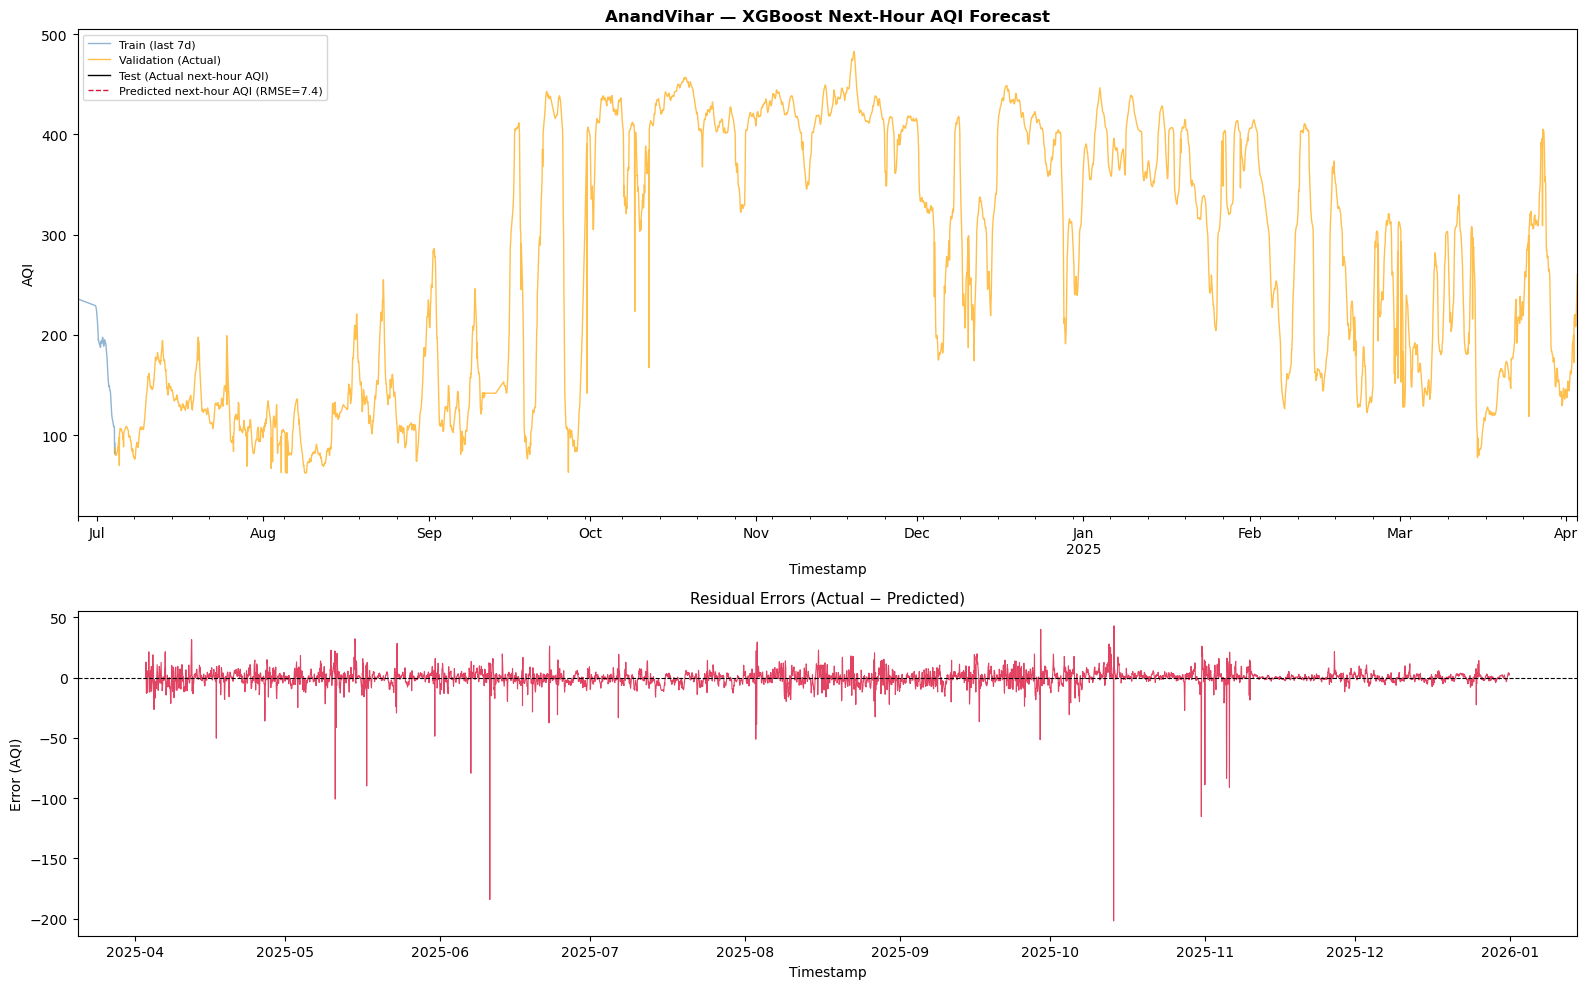

In [8]:
# ── 5b. Plot forecast ─────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(16, 10), gridspec_kw={'height_ratios': [3, 2]})

# ── Panel 1: Full test timeline ────────────────────────────────
ax = axes[0]
last_train = train_df.set_index('Timestamp')['AQI'].iloc[-168:]
last_train.plot(ax=ax, label='Train (last 7d)', color='steelblue', alpha=0.6, lw=1)

val_ts = val_df.set_index('Timestamp')
val_ts['AQI'].plot(ax=ax, label='Validation (Actual)', color='orange', lw=1.0, alpha=0.7)

test_ts = test_df.set_index('Timestamp')
# Actual = AQI_next (the true next-hour AQI)
ax.plot(test_ts.index, y_test.values, label='Test (Actual next-hour AQI)',
        color='black', lw=1.0)
ax.plot(test_ts.index, pred_test,
        label=f'Predicted next-hour AQI (RMSE={rmse:.1f})',
        color='crimson', linestyle='--', lw=1.0)

ax.axvline(x=val_df['Timestamp'].iloc[0],  color='gray', linestyle='--', lw=0.8)
ax.axvline(x=test_df['Timestamp'].iloc[0], color='gray', linestyle='-',  lw=0.8)
ax.set_title(f'{STATION_NAME} — XGBoost Next-Hour AQI Forecast', fontsize=12, fontweight='bold')
ax.set_ylabel('AQI')
ax.legend(fontsize=8, loc='upper left')

# ── Panel 2: Residual errors ───────────────────────────────────
ax2 = axes[1]
errors = y_test.values - pred_test
ax2.plot(test_ts.index, errors, color='crimson', lw=0.8, alpha=0.8)
ax2.axhline(0, color='black', lw=0.8, linestyle='--')
ax2.set_title('Residual Errors (Actual − Predicted)', fontsize=11)
ax2.set_ylabel('Error (AQI)')
ax2.set_xlabel('Timestamp')

plt.tight_layout()
plt.savefig(f'{IMAGE_DIR}/xgboost_forecast_{STATION_NAME}.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Feature Importance

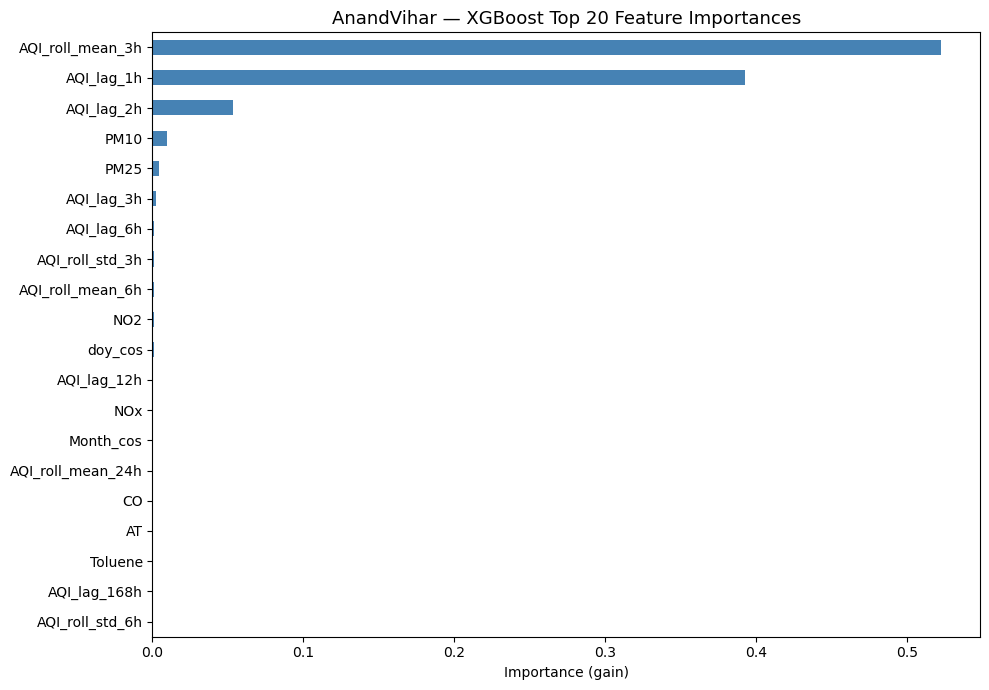


Top 10:
AQI_roll_mean_3h    0.522346
AQI_lag_1h          0.392825
AQI_lag_2h          0.053360
PM10                0.009826
PM25                0.004212
AQI_lag_3h          0.002261
AQI_lag_6h          0.001182
AQI_roll_std_3h     0.000964
AQI_roll_mean_6h    0.000950
NO2                 0.000787


In [9]:
# ── 6. Feature Importance ─────────────────────────────────────
plt.close('all')
importance = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
importance.head(20).plot(kind='barh', ax=ax, color='steelblue')
ax.invert_yaxis()
ax.set_title(f'{STATION_NAME} — XGBoost Top 20 Feature Importances', fontsize=13)
ax.set_xlabel('Importance (gain)')
plt.tight_layout()
plt.savefig(f'{IMAGE_DIR}/xgboost_feature_importance_{STATION_NAME}.png', dpi=130, bbox_inches='tight')
plt.show()

print('\nTop 10:')
print(importance.head(10).to_string())


## 7. Learning Curve

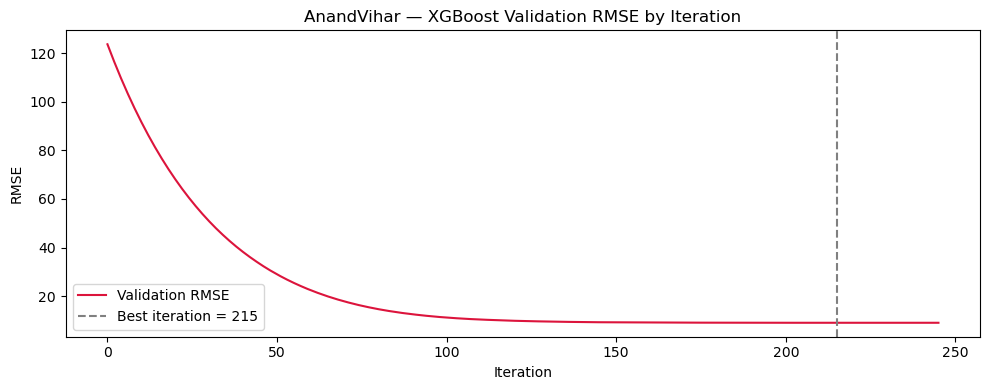

In [10]:
# ── 7. Learning Curve ─────────────────────────────────────────
evals_result = model.evals_result()
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(evals_result['validation_0']['rmse'], label='Validation RMSE', color='crimson')
ax.axvline(model.best_iteration, linestyle='--', color='gray',
           label=f'Best iteration = {model.best_iteration}')
ax.set_title(f'{STATION_NAME} — XGBoost Validation RMSE by Iteration')
ax.set_xlabel('Iteration'); ax.set_ylabel('RMSE')
ax.legend()
plt.tight_layout()
plt.savefig(f'{IMAGE_DIR}/xgboost_learning_curve_{STATION_NAME}.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Classification Metrics & Confusion Matrix
Converting continuous AQI forecasts into discrete AQI categories to evaluate  
classification performance (Accuracy, Precision, Recall).


Classification Metrics — Next-Hour AQI Category:
  Accuracy  : 0.9459
  Precision : 0.9408 (weighted)
  Recall    : 0.9459 (weighted)

              precision    recall  f1-score   support

        Good       0.00      0.00      0.00        44
Satisfactory       0.91      0.95      0.93      1224
    Moderate       0.96      0.96      0.96      2391
        Poor       0.93      0.95      0.94       845
   Very Poor       0.90      0.96      0.93       747
      Severe       1.00      0.94      0.97      1296

    accuracy                           0.95      6547
   macro avg       0.78      0.79      0.79      6547
weighted avg       0.94      0.95      0.94      6547



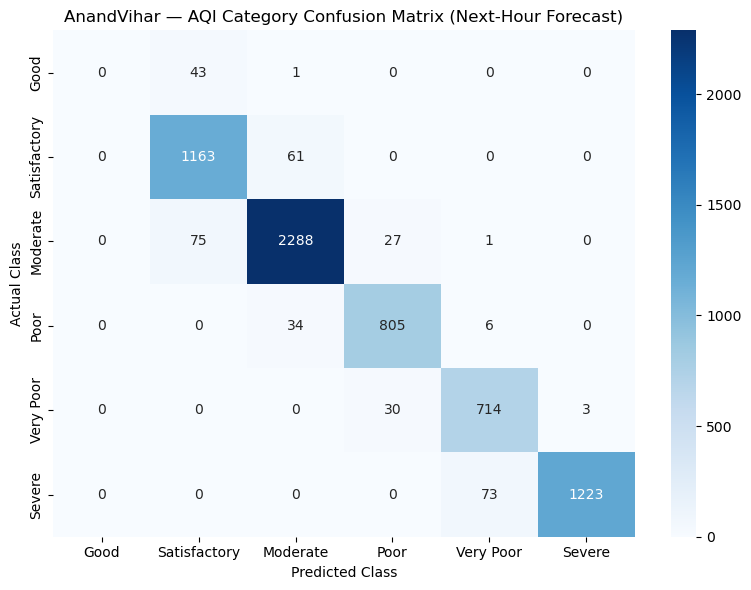

In [11]:
from sklearn.metrics import (confusion_matrix, classification_report,
                              accuracy_score, precision_score, recall_score)
import seaborn as sns

# ── AQI category thresholds (Indian CPCB standard) ────────────
def categorize_aqi(aqi_values):
    cats = []
    for v in aqi_values:
        if   v <= 50:  cats.append('Good')
        elif v <= 100: cats.append('Satisfactory')
        elif v <= 200: cats.append('Moderate')
        elif v <= 300: cats.append('Poor')
        elif v <= 400: cats.append('Very Poor')
        else:          cats.append('Severe')
    return np.array(cats)

y_true_class = categorize_aqi(y_test.values.flatten())
y_pred_class = categorize_aqi(pred_test.flatten())

labels        = ['Good','Satisfactory','Moderate','Poor','Very Poor','Severe']
present_labels = [l for l in labels if l in y_true_class or l in y_pred_class]

acc  = accuracy_score(y_true_class, y_pred_class)
prec = precision_score(y_true_class, y_pred_class, average='weighted', zero_division=0)
rec  = recall_score(y_true_class, y_pred_class, average='weighted', zero_division=0)

print('Classification Metrics — Next-Hour AQI Category:')
print(f'  Accuracy  : {acc:.4f}')
print(f'  Precision : {prec:.4f} (weighted)')
print(f'  Recall    : {rec:.4f} (weighted)\n')
print(classification_report(y_true_class, y_pred_class, labels=present_labels, zero_division=0))

cm = confusion_matrix(y_true_class, y_pred_class, labels=present_labels)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=present_labels, yticklabels=present_labels)
plt.title(f'{STATION_NAME} — AQI Category Confusion Matrix (Next-Hour Forecast)')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.tight_layout()
plt.savefig(f'{IMAGE_DIR}/xgboost_confusion_matrix_{STATION_NAME}.png', dpi=150, bbox_inches='tight')
plt.show()


## 9. Save Model

In [12]:
# ── 9. Save Model ─────────────────────────────────────────────
import joblib, json as _json

model_path = os.path.join(SAVE_DIR, f'{STATION_NAME}_xgboost_aqi.pkl')
joblib.dump(model, model_path)
print(f'✅ Model saved      : {model_path}')

feat_path = os.path.join(SAVE_DIR, f'{STATION_NAME}_xgboost_features.json')
with open(feat_path, 'w') as fp:
    _json.dump(feature_cols, fp)
print(f'✅ Feature list saved: {feat_path}')


✅ Model saved      : D:\AQI_Project_new\XGBOOST\saved_models\AnandVihar_xgboost_aqi.pkl
✅ Feature list saved: D:\AQI_Project_new\XGBOOST\saved_models\AnandVihar_xgboost_features.json


## 10. Inference Example — User Input → Next-Hour AQI

In [13]:
# ── 10. Inference: user provides last-hour readings ───────────
# This mirrors exactly what happens at deployment.
# The user fills in the values they observed in the last hour;
# the model outputs predicted AQI for the next hour.
#
# For a real deployment load the saved model:
#   model      = joblib.load(model_path)
#   feature_cols = json.load(open(feat_path))

import joblib, json as _json
import numpy as np
import pandas as pd

# Example: fill with your observed values from the last hour
user_input = {
    # ── Pollutants at hour t (user-supplied) ──
    'PM2.5'  : 85.0,
    'PM10'   : 140.0,
    'NO'     : 18.0,
    'NO2'    : 32.0,
    'NOx'    : 50.0,
    'NH3'    : 10.0,
    'SO2'    : 12.0,
    'CO'     : 1.2,
    'O3'     : 45.0,
    # ── AQI lags — fill from recent history ───
    'AQI_lag_1h'  : 180.0,
    'AQI_lag_2h'  : 175.0,
    'AQI_lag_3h'  : 170.0,
    'AQI_lag_6h'  : 160.0,
    'AQI_lag_12h' : 155.0,
    'AQI_lag_24h' : 145.0,
    'AQI_lag_48h' : 130.0,
    'AQI_lag_72h' : 125.0,
    'AQI_lag_168h': 110.0,
    # ── Rolling stats — compute from AQI history ─
    'AQI_roll_mean_3h'  : 175.0,
    'AQI_roll_std_3h'   : 5.0,
    'AQI_roll_mean_6h'  : 165.0,
    'AQI_roll_std_6h'   : 8.0,
    'AQI_roll_mean_24h' : 150.0,
    'AQI_roll_std_24h'  : 15.0,
    # ── Calendar features (auto-computed from current timestamp) ─
    'Hour_sin'  : np.sin(2 * np.pi * 14 / 24),   # 2 PM
    'Hour_cos'  : np.cos(2 * np.pi * 14 / 24),
    'Month_sin' : np.sin(2 * np.pi * 1 / 12),    # January
    'Month_cos' : np.cos(2 * np.pi * 1 / 12),
    'IsWeekend' : 0,
    'doy_sin'   : np.sin(2 * np.pi * 15 / 365),  # Jan 15
    'doy_cos'   : np.cos(2 * np.pi * 15 / 365),
}

# Build input row aligned to model's feature order
row = pd.DataFrame([{col: user_input.get(col, 0.0) for col in feature_cols}])
predicted_aqi = model.predict(row)[0]

def categorize_aqi_single(v):
    if   v <= 50:  return 'Good'
    elif v <= 100: return 'Satisfactory'
    elif v <= 200: return 'Moderate'
    elif v <= 300: return 'Poor'
    elif v <= 400: return 'Very Poor'
    else:          return 'Severe'

print(f'Predicted next-hour AQI : {predicted_aqi:.1f}  ({categorize_aqi_single(predicted_aqi)})')


Predicted next-hour AQI : 174.2  (Moderate)
